In [21]:
# ==============================
# Import Required Libraries
# ==============================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, accuracy_score

In [22]:
import yfinance as yf
import pandas as pd

ticker = "RELIANCE.NS"   # More stable than ^NSEI

data = yf.download(
    ticker,
    start="2012-01-01",
    end="2024-12-31",
    auto_adjust=False,
    progress=False
)

# if data.empty:
#     raise ValueError("Data download failed. Check ticker symbol.")

# Fix multi-index columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[['Open','High','Low','Close','Volume']].copy()
data.dropna(inplace=True)

data.head()

Failed to get ticker 'RELIANCE.NS' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['RELIANCE.NS']: Exception('%ticker%: No timezone found, symbol may be delisted')


,Open,High,Low,Close,Volume
Date,,,,,


In [23]:
!pip install --upgrade yfinance

You should consider upgrading via the 'E:\My_Project\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [24]:
# ==============================
# Feature Engineering
# ==============================

# Moving Averages
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

# RSI
delta = data['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

# MACD
ema12 = data['Close'].ewm(span=12).mean()
ema26 = data['Close'].ewm(span=26).mean()
data['MACD'] = ema12 - ema26

# Bollinger Bands
data['BB_upper'] = data['MA20'] + 2 * data['Close'].rolling(20).std()
data['BB_lower'] = data['MA20'] - 2 * data['Close'].rolling(20).std()

# MA Crossover Signal
data['MA_signal'] = np.where(data['MA20'] > data['MA50'], 1, 0)

# Targets
data['Target_reg'] = data['Close'].shift(-1)
data['Target_class'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)

data.dropna(inplace=True)

data.head()

,Open,High,Low,Close,Volume,MA20,MA50,RSI,MACD,BB_upper,BB_lower,MA_signal,Target_reg,Target_class
Date,,,,,,,,,,,,,,


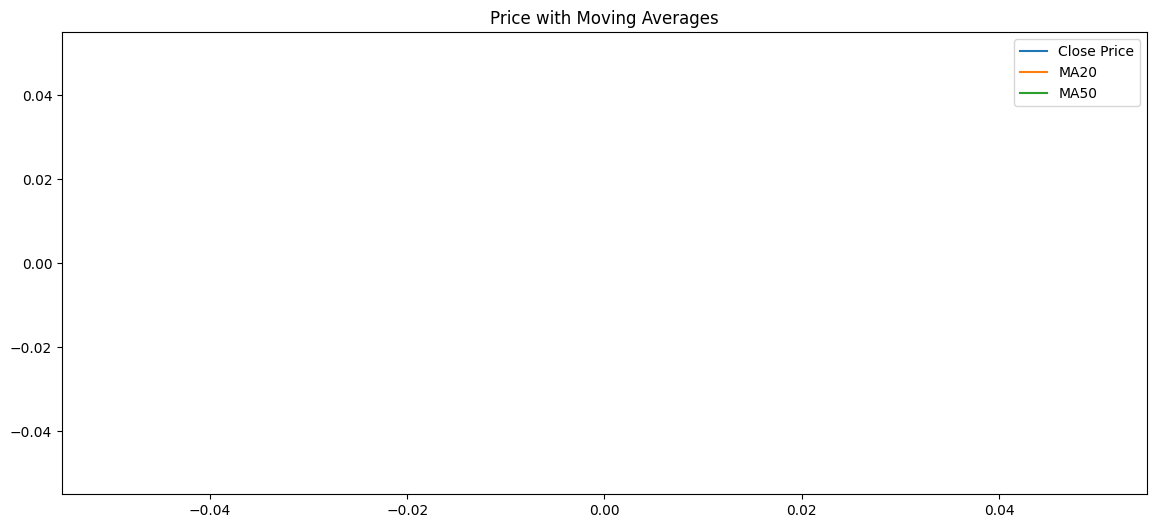

e:\My_Project\venv\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
e:\My_Project\venv\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


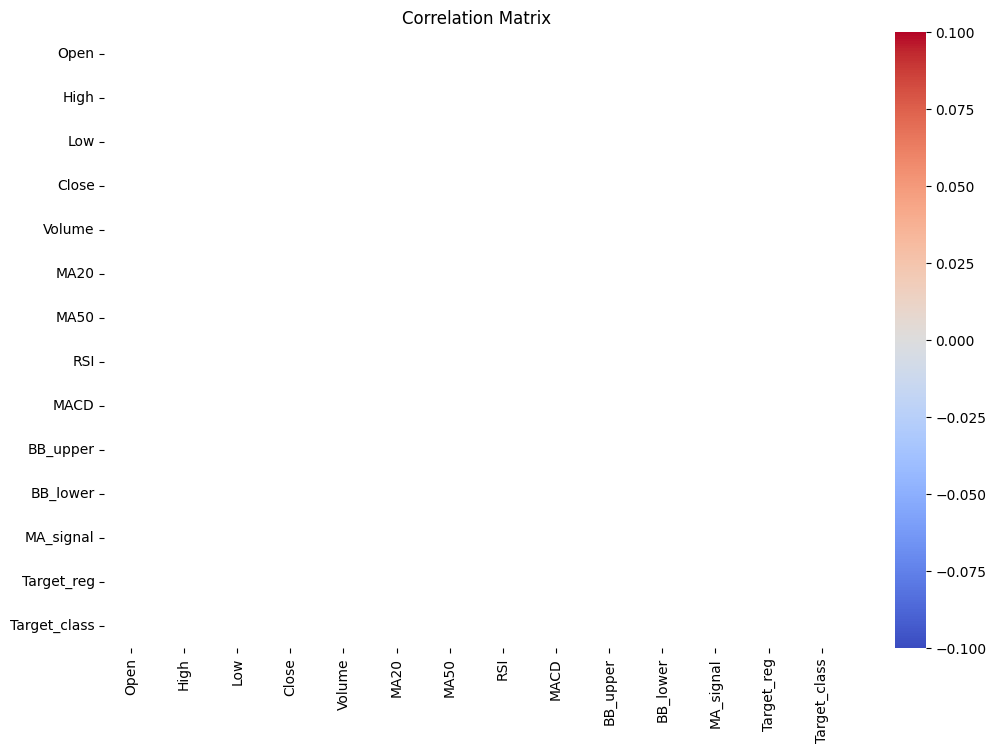

In [25]:
# ==============================
# Visualizations
# ==============================

plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA20'], label='MA20')
plt.plot(data['MA50'], label='MA50')
plt.legend()
plt.title("Price with Moving Averages")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [26]:
# ==============================
# Scaling + PCA
# ==============================

features = data.drop(['Target_reg','Target_class'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

ValueError: Found array with 0 sample(s) (shape=(0, 12)) while a minimum of 1 is required by StandardScaler.

In [ ]:
# ==============================
# Train Test Split
# ==============================

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X_pca, data['Target_reg'], test_size=0.2, shuffle=False)

_, _, y_train_clf, y_test_clf = train_test_split(
    X_pca, data['Target_class'], test_size=0.2, shuffle=False)

In [ ]:
# ==============================
# Regression Model
# ==============================

rf = RandomForestRegressor()
rf.fit(X_train, y_train_reg)

pred_reg = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_reg, pred_reg))
print("Regression RMSE:", rmse)

In [ ]:
# ==============================
# Classification Model
# ==============================

clf = LogisticRegression()
clf.fit(X_train, y_train_clf)

pred_clf = clf.predict(X_test)

acc = accuracy_score(y_test_clf, pred_clf)
print("Classification Accuracy:", acc)

In [ ]:
# ==============================
# Market Regime Clustering
# ==============================

kmeans = KMeans(n_clusters=3)
data['Market_Regime'] = kmeans.fit_predict(X_pca)

data[['Close','Market_Regime']].head()

In [ ]:
# ==============================
# Prediction Visualization
# ==============================

plt.figure(figsize=(14,6))
plt.plot(y_test_reg.values, label="Actual")
plt.plot(pred_reg, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Price")
plt.show()